# Implementación de una técnica de aprendizaje máquina sin el uso de un framework

## Alfredo Alejandro Soto Herrera - A01711368


In [1]:
from google.colab import drive
drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [2]:
%cd "/content/gdrive/MyDrive/Concentracion_ia/Proyecto"
!ls

/content/gdrive/MyDrive/Concentracion_ia/Proyecto
college_sleep_and_gpa.csv  df_processed.csv


In [3]:
import pandas as pd

df = pd.read_csv('college_sleep_and_gpa.csv')
df.head()

,student_id,study,university,semester,cohort_code,gender,first_generation,underrepresented,avg_sleep_minutes,avg_sleep_hours,...,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_units,term_load_z,under_6h_sleep,sleep_bracket,sleep_midpoint_clock
0,293,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,370.0,6.17,...,0.0500,0.931,4.00,3.76,-0.24,49.0,0.112,0,6-6.5h,07:20
1,294,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,406.8,6.78,...,0.0476,0.862,4.00,3.55,-0.45,49.0,0.112,0,6.5-7h,05:00
2,297,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,1.0,253.8,4.23,...,0.1639,0.586,3.00,3.59,0.59,46.0,-0.604,1,<5.5h,05:38
3,303,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,411.9,6.86,...,0.7854,0.931,3.80,3.46,-0.34,39.0,-2.275,0,6.5-7h,07:52
4,304,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,1.0,408.1,6.80,...,0.1538,0.931,3.17,3.50,0.33,39.0,-2.275,0,6.5-7h,04:54


## EDA Inicial

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               634 non-null    int64  
 1   study                    634 non-null    int64  
 2   university               634 non-null    object 
 3   semester                 634 non-null    object 
 4   cohort_code              634 non-null    object 
 5   gender                   631 non-null    object 
 6   first_generation         630 non-null    float64
 7   underrepresented         633 non-null    float64
 8   avg_sleep_minutes        634 non-null    float64
 9   avg_sleep_hours          634 non-null    float64
 10  daytime_sleep_minutes    634 non-null    float64
 11  sleep_midpoint_minutes   634 non-null    float64
 12  bedtime_variability      634 non-null    float64
 13  nights_tracked_fraction  634 non-null    float64
 14  prior_gpa                6

In [5]:
print("Valores Faltantes")
missing = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_table = pd.DataFrame({"Valores faltantes": missing, "Porcentaje": missing_percentage})
print(missing_table[missing_table["Valores faltantes"] > 0])

Valores Faltantes
                  Valores faltantes  Porcentaje
gender                            3    0.473186
first_generation                  4    0.630915
underrepresented                  1    0.157729
term_units                      147   23.186120
term_load_z                     147   23.186120


In [6]:
duplicates = df.duplicated().sum()
print(f"Filas duplicadas: {duplicates}")

Filas duplicadas: 0


In [7]:
print(df.describe())

         student_id       study  first_generation  underrepresented  \
count    634.000000  634.000000        630.000000        633.000000   
mean   13005.892744    3.181388          0.166667          0.187994   
std    26496.593477    1.317125          0.377213          0.391016   
min        1.000000    1.000000          0.000000          0.000000   
25%      178.000000    2.000000          0.000000          0.000000   
50%      358.500000    3.000000          0.000000          0.000000   
75%      592.750000    4.000000          0.000000          0.000000   
max    99978.000000    5.000000          2.000000          1.000000   

       avg_sleep_minutes  avg_sleep_hours  daytime_sleep_minutes  \
count         634.000000       634.000000             634.000000   
mean          397.324763         6.622098              41.165615   
std            50.855641         0.847741              27.388294   
min           194.800000         3.250000               2.300000   
25%           366.95

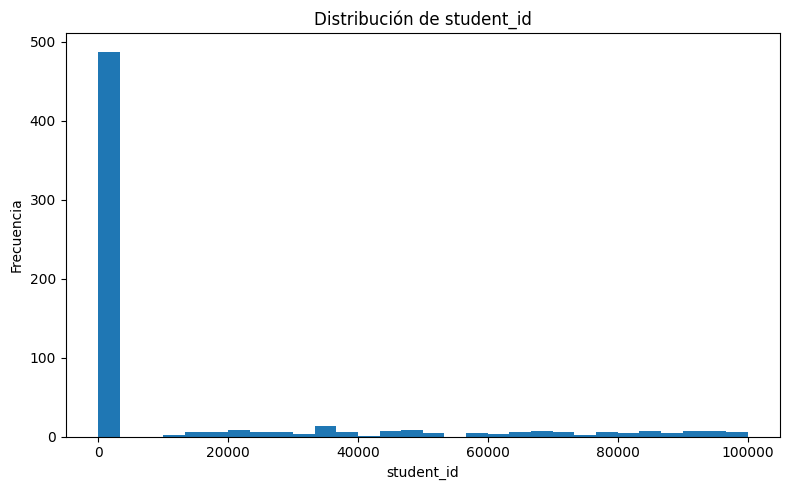

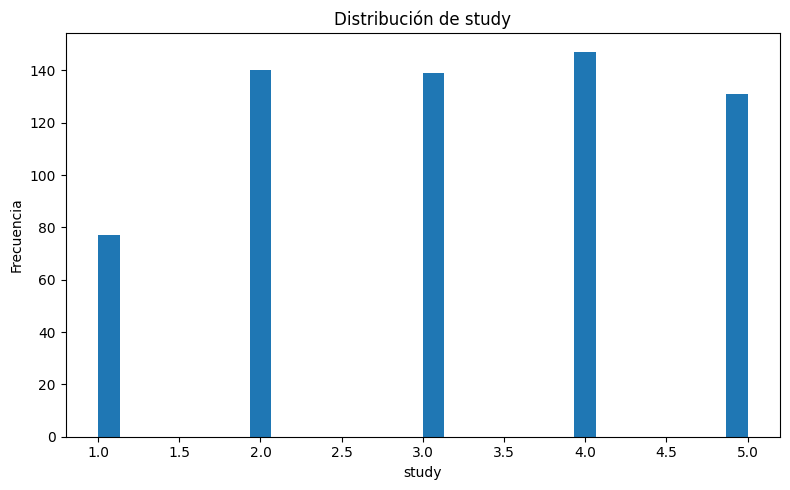

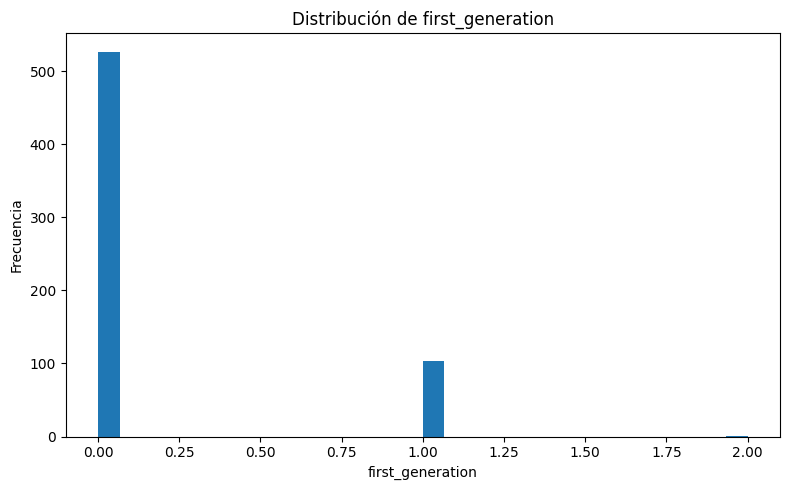

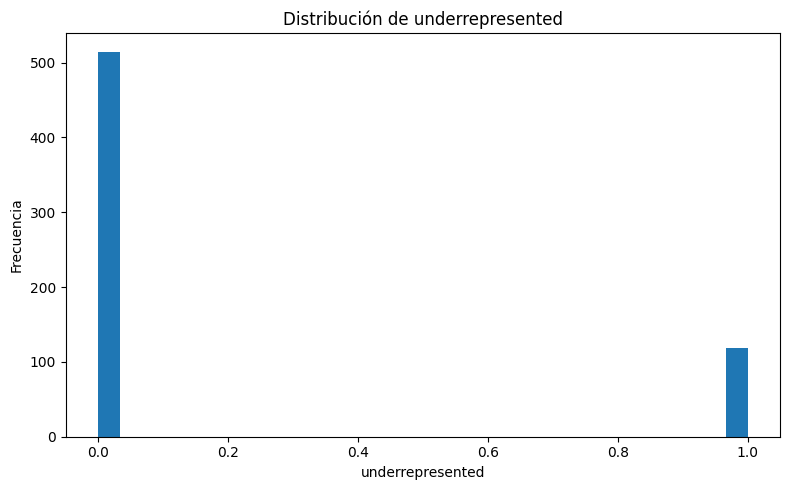

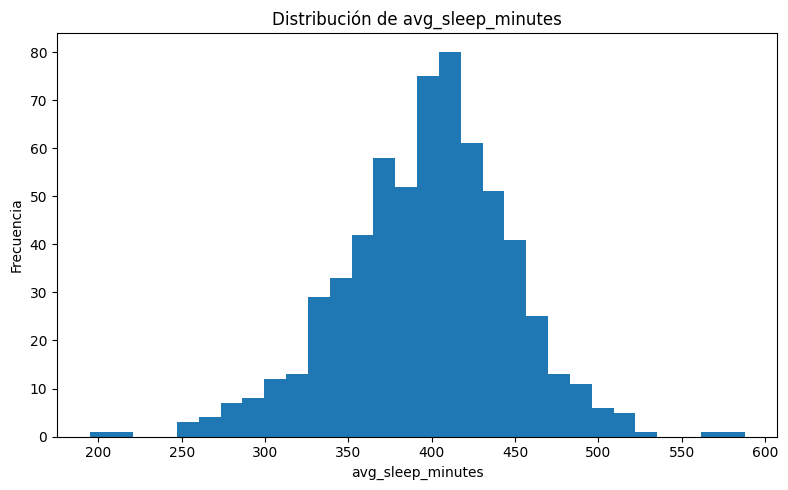

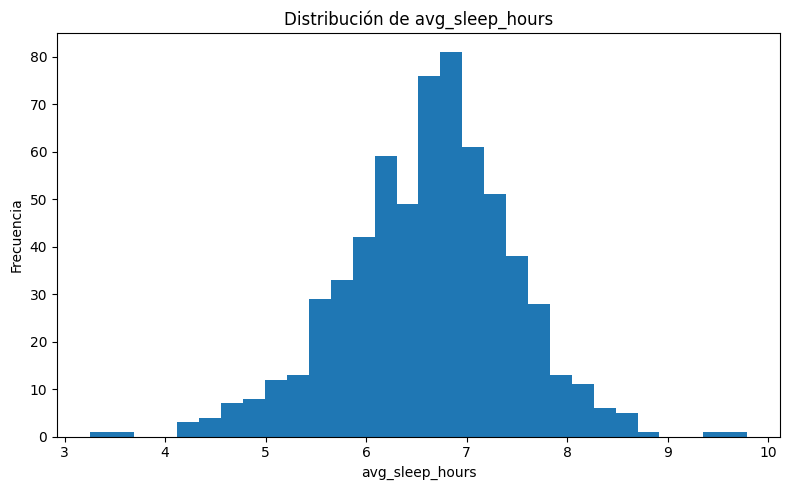

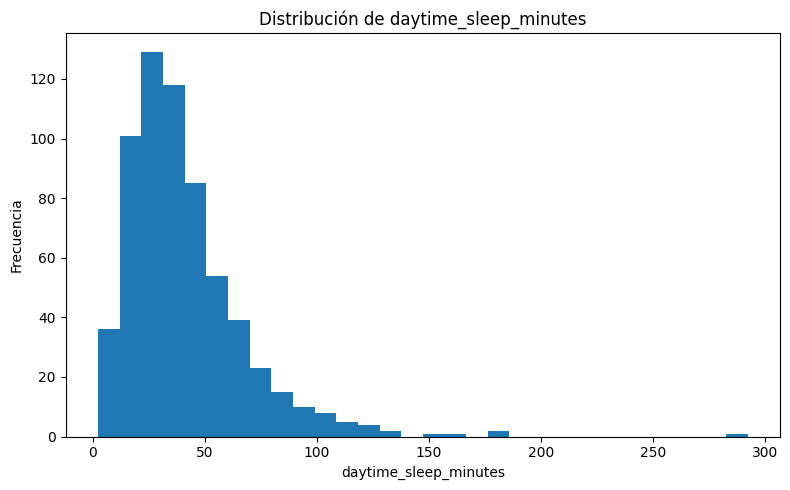

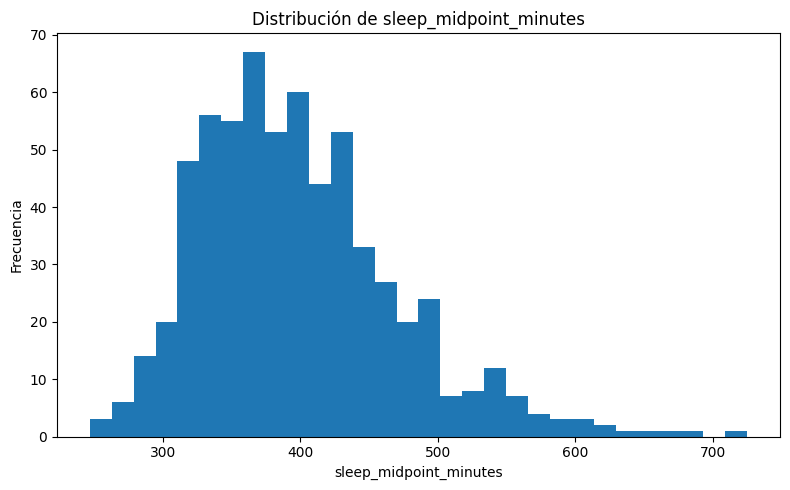

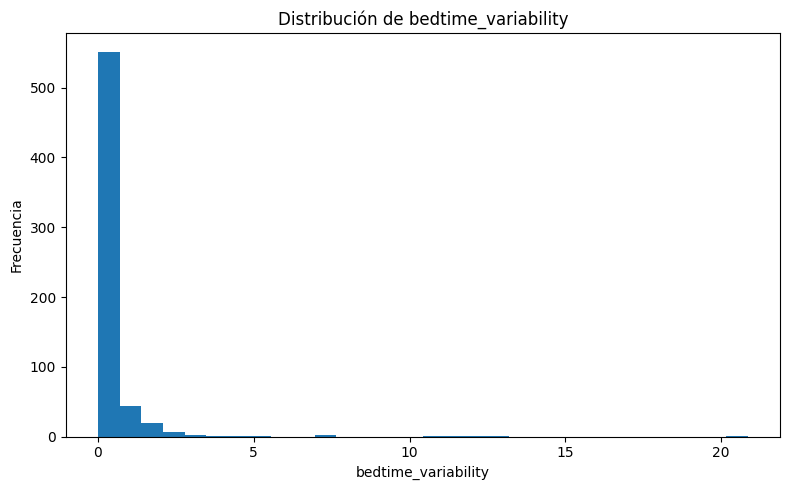

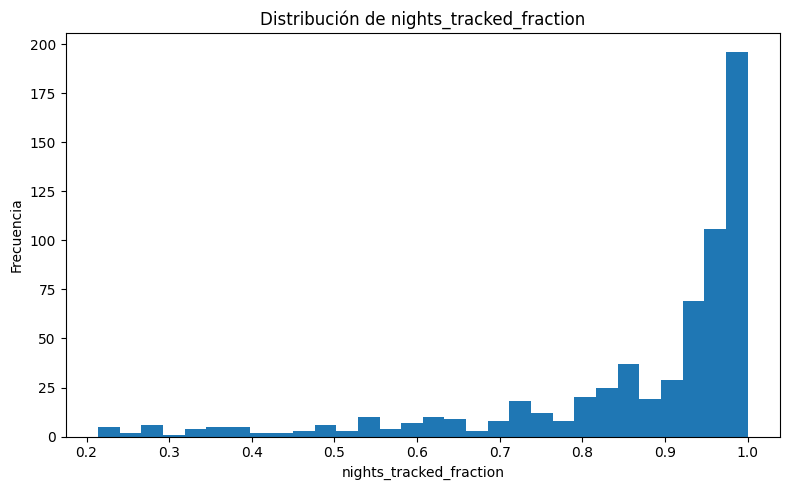

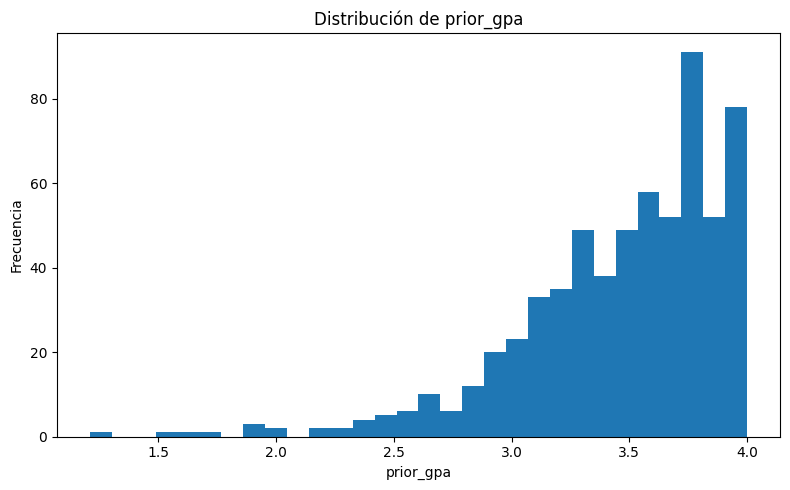

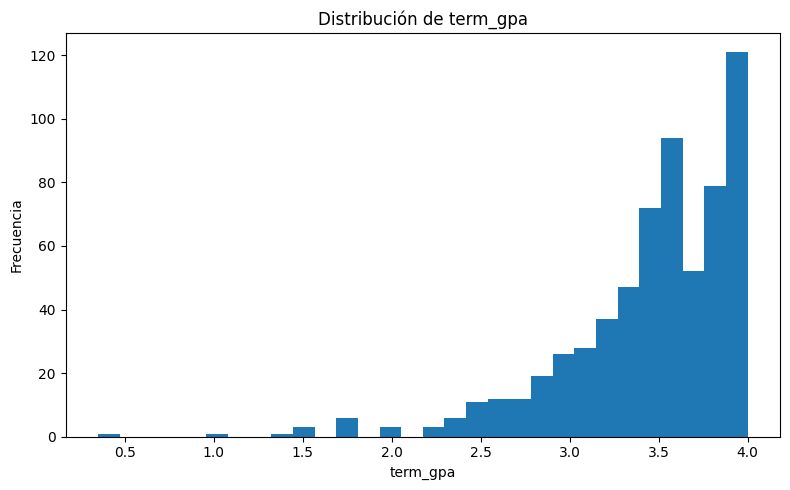

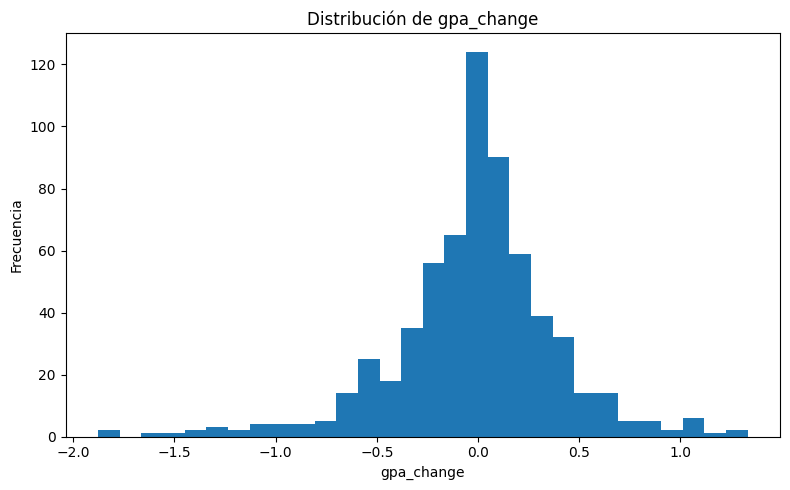

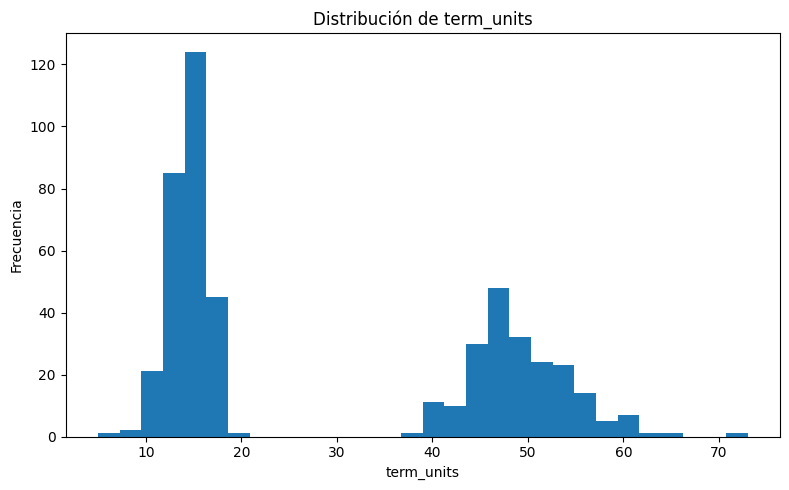

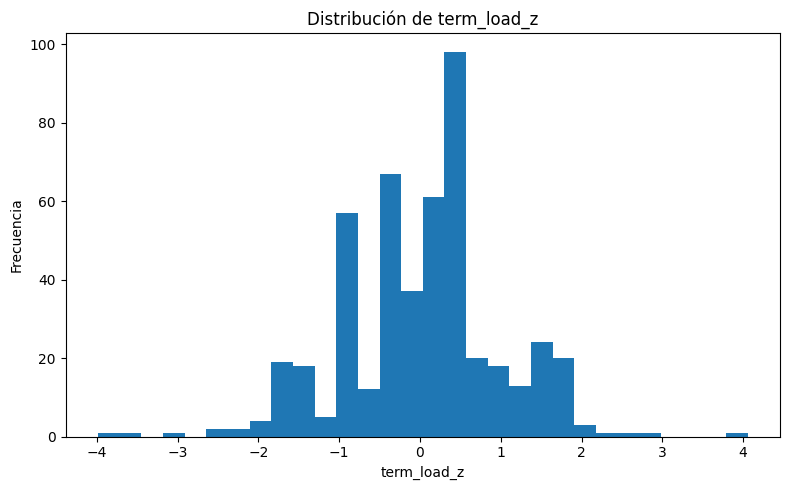

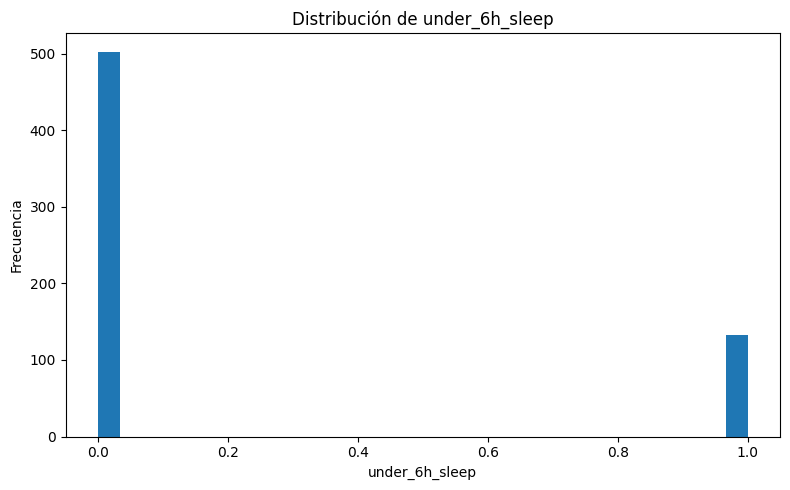

In [8]:
import numpy as np
import matplotlib.pyplot as plt
numeric_columns = df.select_dtypes(include=np.number).columns
for column in numeric_columns:
    plt.figure(figsize=(8, 5))
    plt.hist(df[column].dropna(), bins=30)
    plt.title(f"Distribución de {column}")
    plt.xlabel(column)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

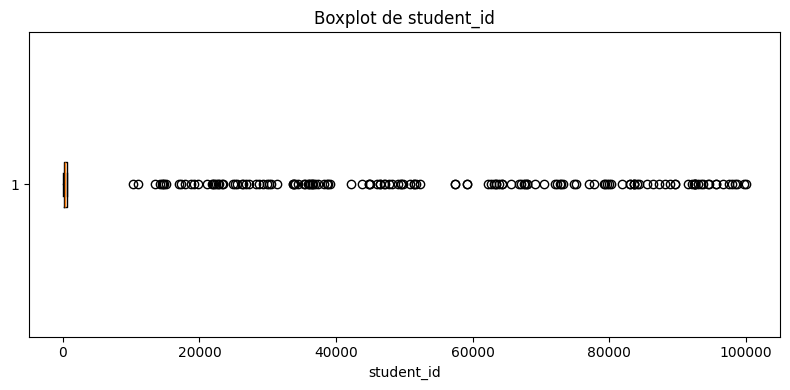

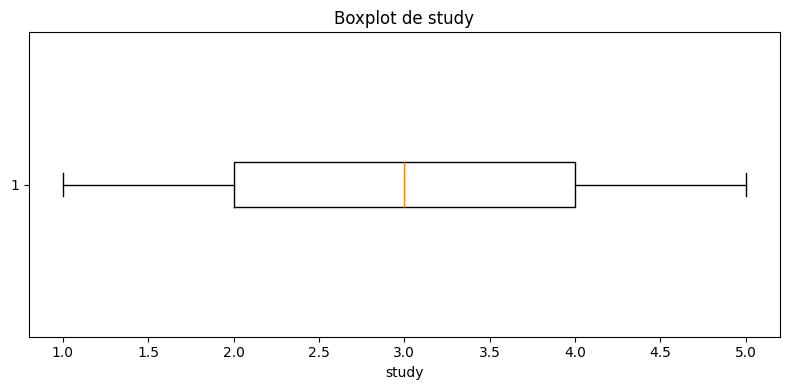

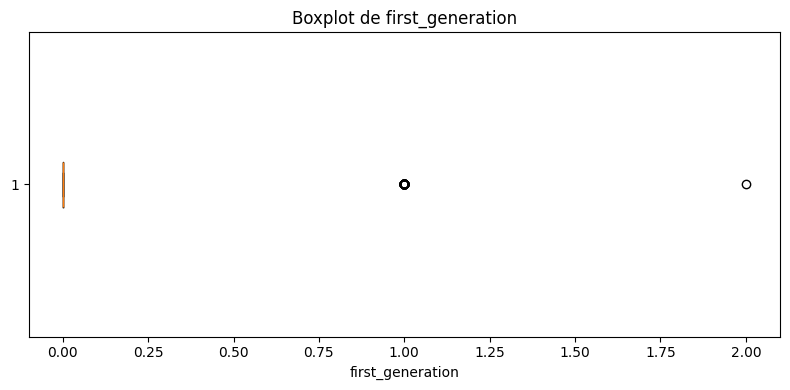

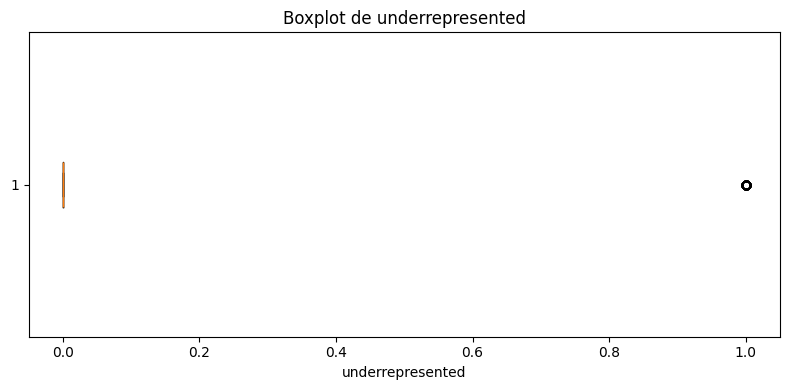

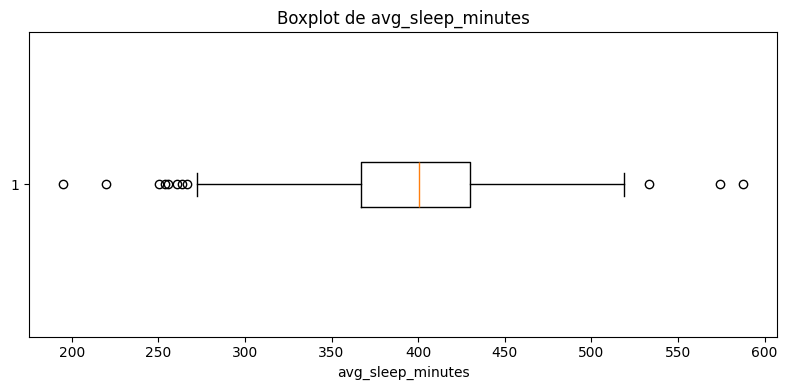

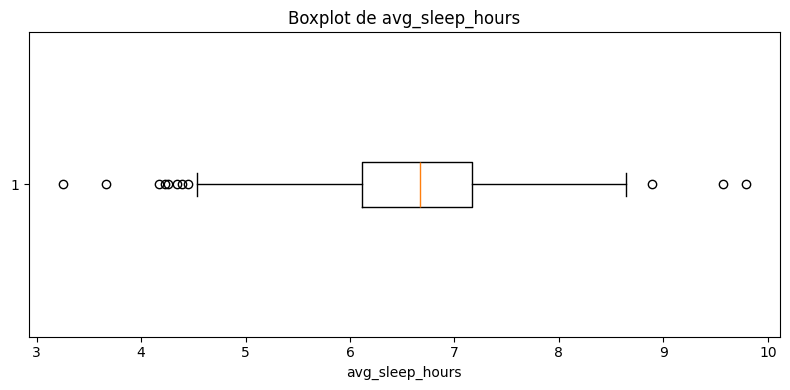

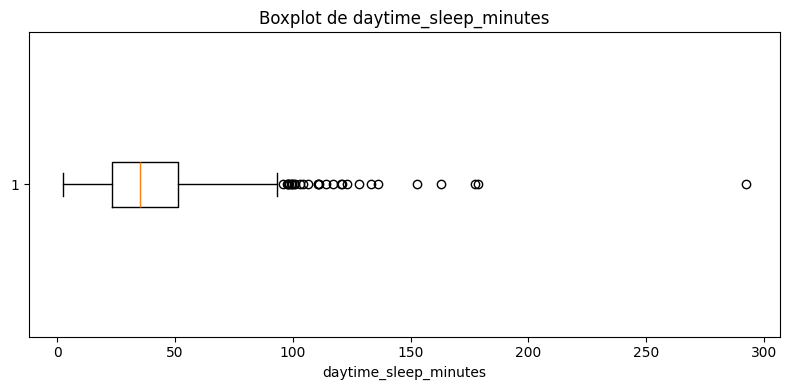

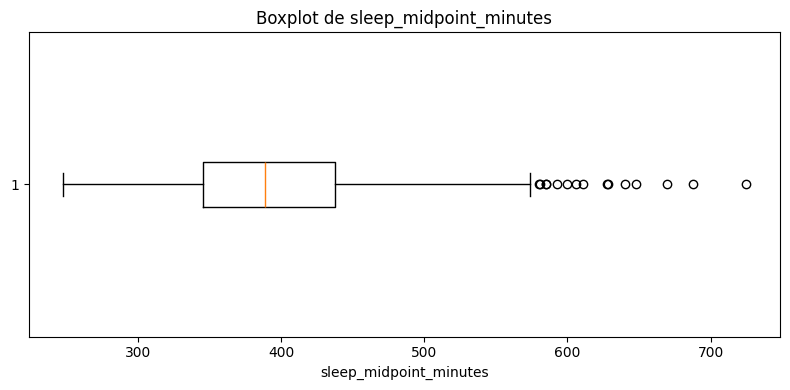

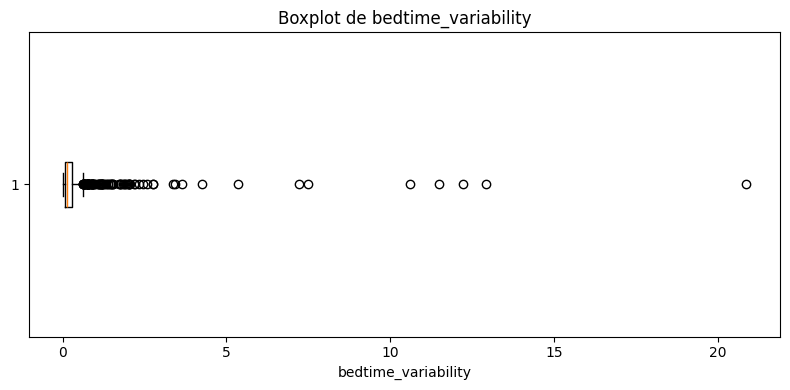

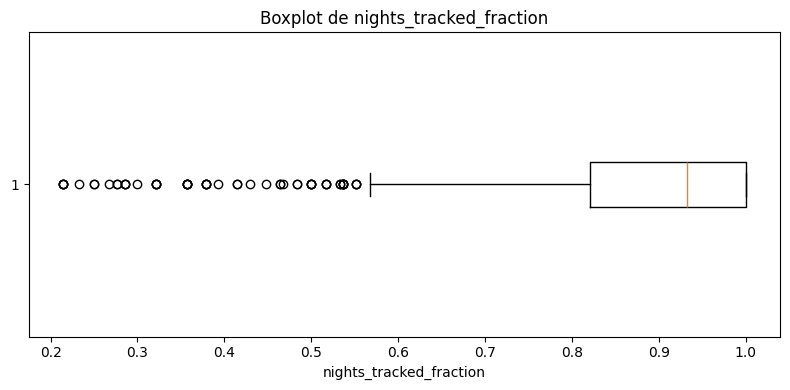

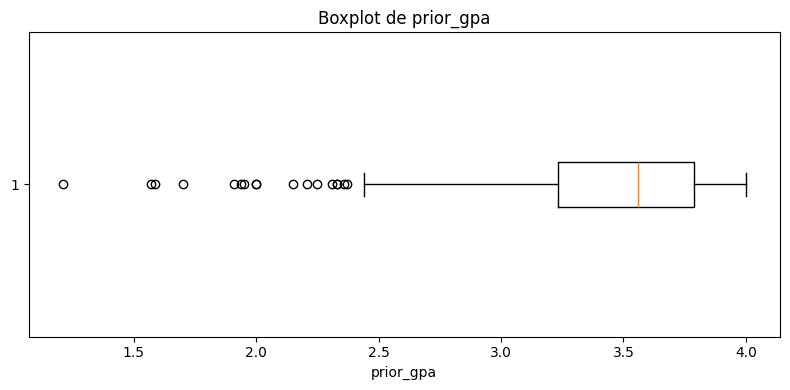

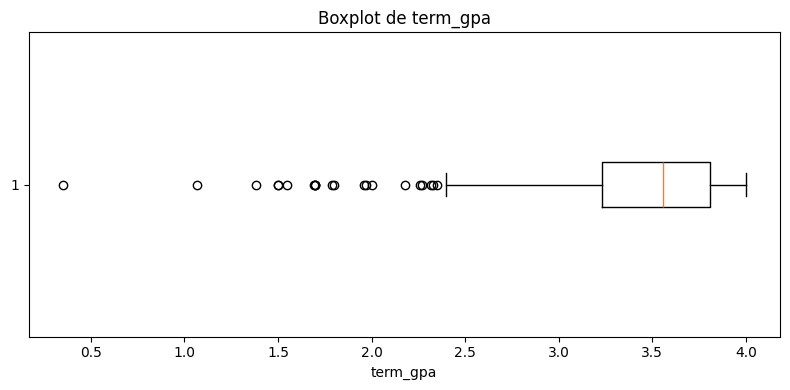

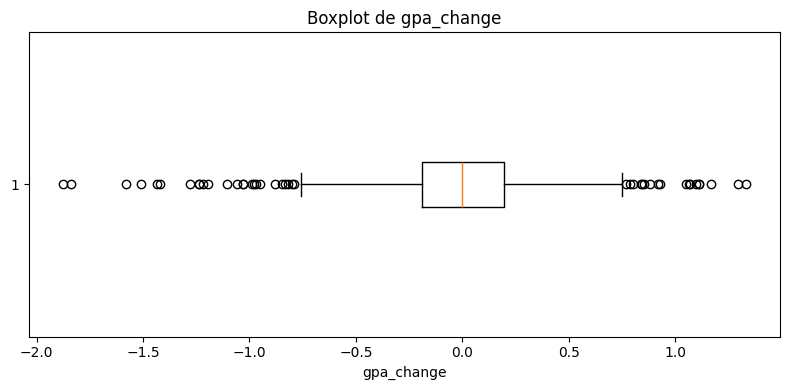

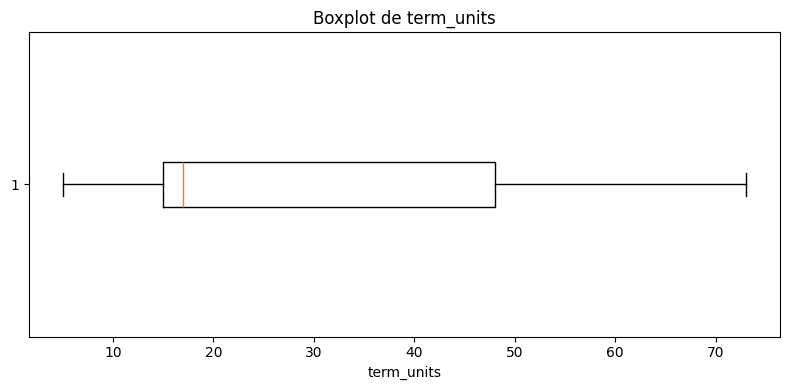

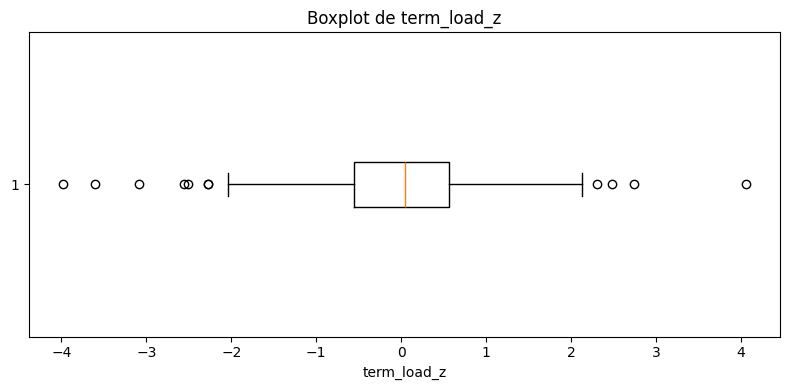

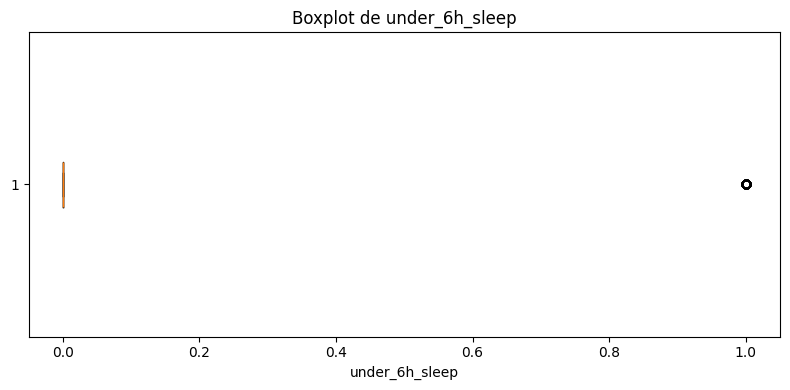

In [9]:
for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[column].dropna(), vert=False)
    plt.title(f"Boxplot de {column}")
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()

In [10]:
correlation_matrix = df[numeric_columns].corr()

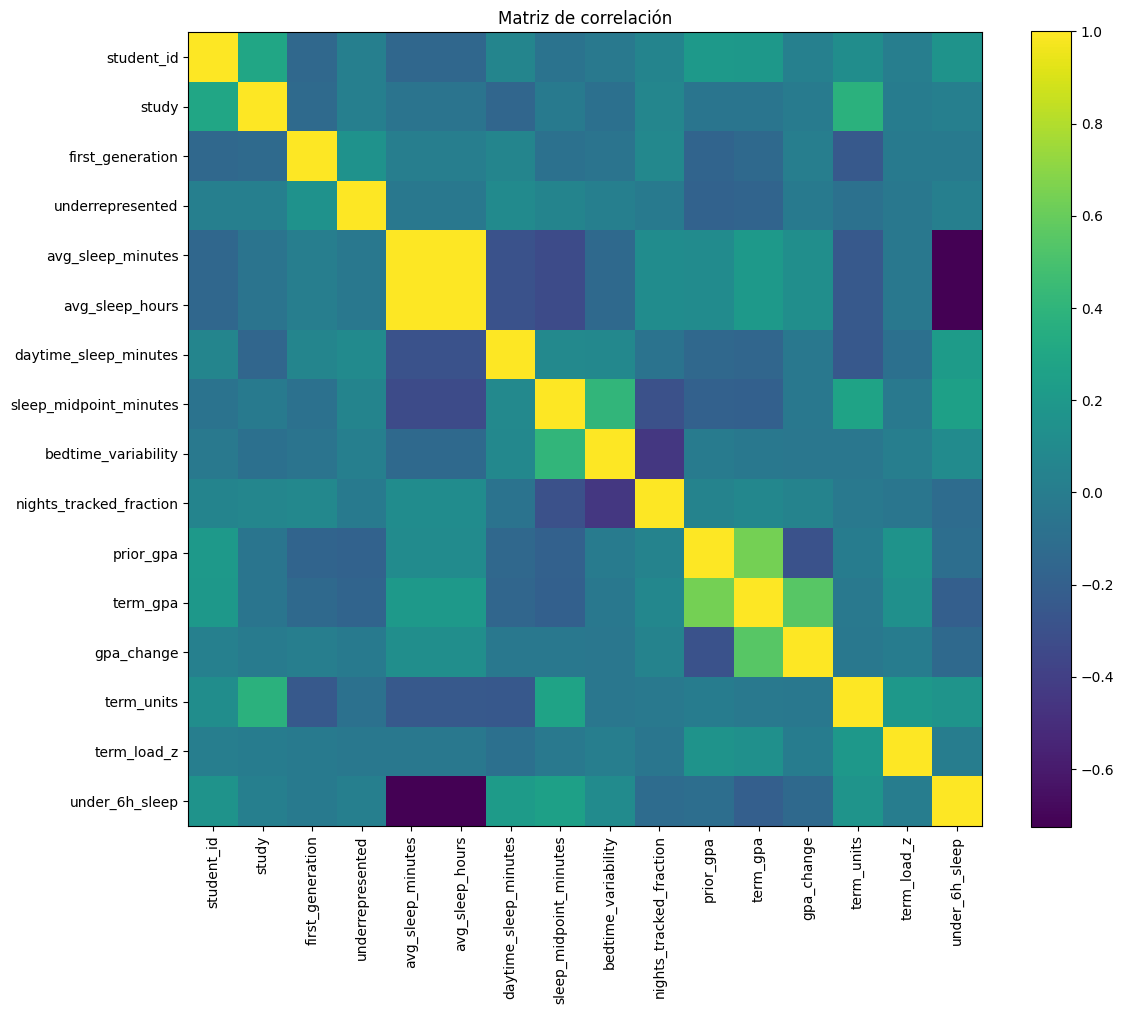

In [11]:
plt.figure(figsize=(12, 10))
plt.imshow(correlation_matrix, interpolation="nearest")
plt.colorbar()
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

In [12]:
target_correlations = (df[numeric_columns].corr()["term_gpa"].sort_values(ascending=False))
print("Correlación con GPA")
print(target_correlations)

Correlación con GPA
term_gpa                   1.000000
prior_gpa                  0.638025
gpa_change                 0.548917
avg_sleep_minutes          0.201674
avg_sleep_hours            0.201542
student_id                 0.196675
term_load_z                0.140652
nights_tracked_fraction    0.074180
term_units                -0.030672
bedtime_variability       -0.035967
study                     -0.056451
first_generation          -0.135061
daytime_sleep_minutes     -0.153059
underrepresented          -0.170013
sleep_midpoint_minutes    -0.194537
under_6h_sleep            -0.199581
Name: term_gpa, dtype: float64


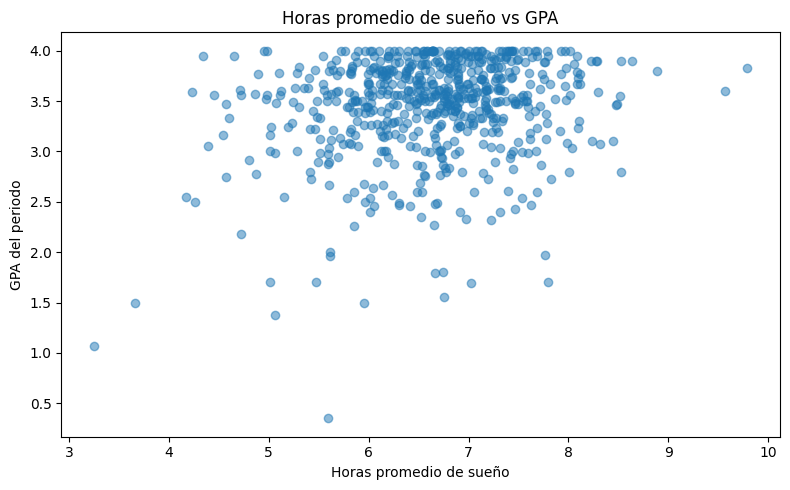

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(df["avg_sleep_hours"], df["term_gpa"], alpha=0.5)
plt.title("Horas promedio de sueño vs GPA")
plt.xlabel("Horas promedio de sueño")
plt.ylabel("GPA del periodo")
plt.tight_layout()
plt.show()

## ETL

In [14]:
df = df.drop(["student_id","study","university","semester","cohort_code","avg_sleep_minutes","gpa_change","term_units","term_load_z","under_6h_sleep","sleep_bracket","sleep_midpoint_clock"], axis=1)

In [15]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   gender                   631 non-null    object 
 1   first_generation         630 non-null    float64
 2   underrepresented         633 non-null    float64
 3   avg_sleep_hours          634 non-null    float64
 4   daytime_sleep_minutes    634 non-null    float64
 5   sleep_midpoint_minutes   634 non-null    float64
 6   bedtime_variability      634 non-null    float64
 7   nights_tracked_fraction  634 non-null    float64
 8   prior_gpa                634 non-null    float64
 9   term_gpa                 634 non-null    float64
dtypes: float64(9), object(1)
memory usage: 49.7+ KB
None


In [16]:
print(df.isnull().sum())

gender                     3
first_generation           4
underrepresented           1
avg_sleep_hours            0
daytime_sleep_minutes      0
sleep_midpoint_minutes     0
bedtime_variability        0
nights_tracked_fraction    0
prior_gpa                  0
term_gpa                   0
dtype: int64


In [17]:
print(df.describe())

       first_generation  underrepresented  avg_sleep_hours  \
count        630.000000        633.000000       634.000000   
mean           0.166667          0.187994         6.622098   
std            0.377213          0.391016         0.847741   
min            0.000000          0.000000         3.250000   
25%            0.000000          0.000000         6.112500   
50%            0.000000          0.000000         6.675000   
75%            0.000000          0.000000         7.170000   
max            2.000000          1.000000         9.790000   

       daytime_sleep_minutes  sleep_midpoint_minutes  bedtime_variability  \
count             634.000000              634.000000           634.000000   
mean               41.165615              398.678707             0.451687   
std                27.388294               72.712017             1.393631   
min                 2.300000              247.100000             0.004500   
25%                23.100000              345.175000    

In [18]:
df["gender"] = df["gender"].fillna(df["gender"].mode()[0])
df["underrepresented"] = df["underrepresented"].fillna(df["underrepresented"].mode()[0])
print(df["first_generation"].value_counts(dropna=False))

first_generation
0.0    526
1.0    103
NaN      4
2.0      1
Name: count, dtype: int64


In [19]:
df["first_generation"] = df["first_generation"].replace(2, np.nan)
df["first_generation"] = df["first_generation"].fillna(df["first_generation"].mode()[0])

In [20]:
def detectar_outliers_iqr(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]
    return outliers, Q1, Q3, IQR, limite_inferior, limite_superior

In [21]:
numeric_columns = df.select_dtypes(include=np.number).columns
outlier_summary = []
for columna in numeric_columns:
    outliers, Q1, Q3, IQR, lower, upper = detectar_outliers_iqr(df, columna)
    outlier_summary.append({
        "variable": columna,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "limite_inferior": lower,
        "limite_superior": upper,
        "cantidad_outliers": len(outliers),
        "porcentaje_outliers": len(outliers) / len(df) * 100
    })
outlier_summary = pd.DataFrame(outlier_summary)
print(outlier_summary)

                  variable         Q1        Q3       IQR  limite_inferior  \
0         first_generation    0.00000    0.0000   0.00000         0.000000   
1         underrepresented    0.00000    0.0000   0.00000         0.000000   
2          avg_sleep_hours    6.11250    7.1700   1.05750         4.526250   
3    daytime_sleep_minutes   23.10000   51.2500  28.15000       -19.125000   
4   sleep_midpoint_minutes  345.17500  437.6250  92.45000       206.500000   
5      bedtime_variability    0.07470    0.2917   0.21700        -0.250800   
6  nights_tracked_fraction    0.82100    1.0000   0.17900         0.552500   
7                prior_gpa    3.23225    3.7895   0.55725         2.396375   
8                 term_gpa    3.23300    3.8100   0.57700         2.367500   

   limite_superior  cantidad_outliers  porcentaje_outliers  
0         0.000000                103            16.246057  
1         0.000000                119            18.769716  
2         8.756250                 1

In [22]:
df = df.loc[df["daytime_sleep_minutes"] <= 200]
df = df.loc[df["bedtime_variability"] <= 5]

## EDA Final

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 625 entries, 0 to 633
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   gender                   625 non-null    object 
 1   first_generation         625 non-null    float64
 2   underrepresented         625 non-null    float64
 3   avg_sleep_hours          625 non-null    float64
 4   daytime_sleep_minutes    625 non-null    float64
 5   sleep_midpoint_minutes   625 non-null    float64
 6   bedtime_variability      625 non-null    float64
 7   nights_tracked_fraction  625 non-null    float64
 8   prior_gpa                625 non-null    float64
 9   term_gpa                 625 non-null    float64
dtypes: float64(9), object(1)
memory usage: 53.7+ KB


In [24]:
df.describe()

,first_generation,underrepresented,avg_sleep_hours,daytime_sleep_minutes,sleep_midpoint_minutes,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa
count,625.000000,625.000000,625.000000,625.00000,625.00000,625.000000,625.000000,625.000000,625.000000
mean,0.164800,0.188800,6.629424,40.64336,397.09120,0.316060,0.874950,3.463622,3.450187
std,0.371297,0.391663,0.833920,25.28036,70.24673,0.513144,0.167706,0.438481,0.493393
min,0.000000,0.000000,3.660000,2.30000,247.10000,0.004500,0.214000,1.210000,0.350000
25%,0.000000,0.000000,6.120000,23.10000,345.00000,0.073000,0.828000,3.230000,3.233000
50%,0.000000,0.000000,6.680000,35.00000,386.90000,0.131900,0.933000,3.556000,3.556000
75%,0.000000,0.000000,7.170000,51.00000,436.20000,0.271200,1.000000,3.780000,3.810000
max,1.000000,1.000000,9.790000,178.50000,687.50000,4.255400,1.000000,4.000000,4.000000


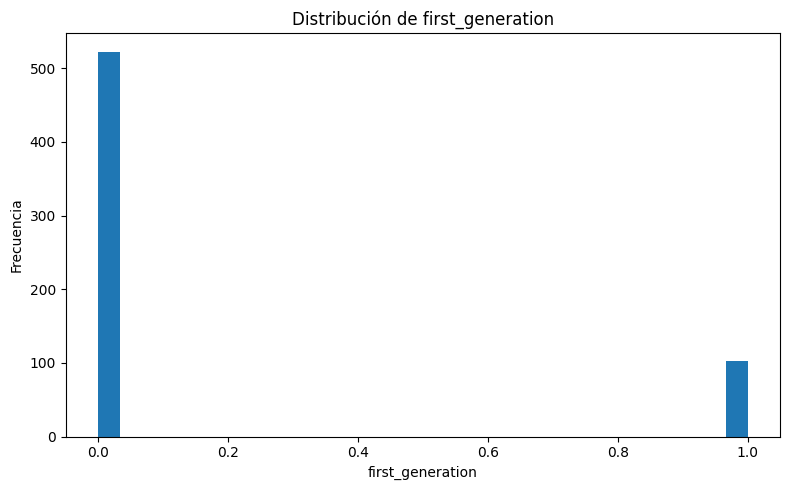

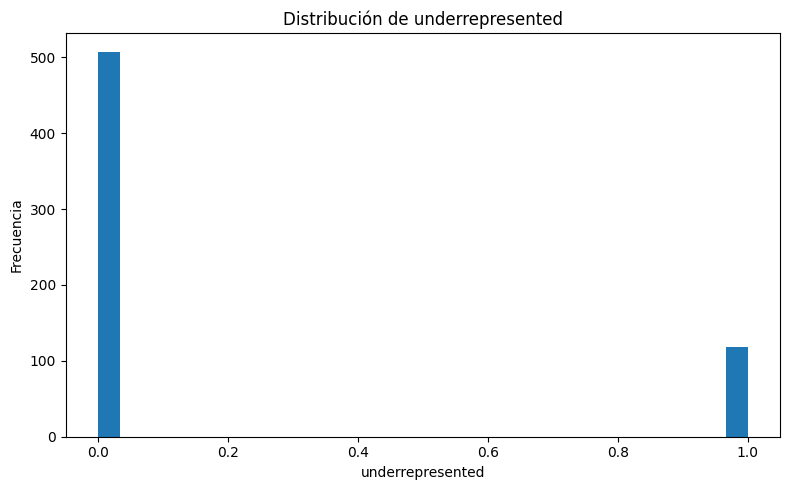

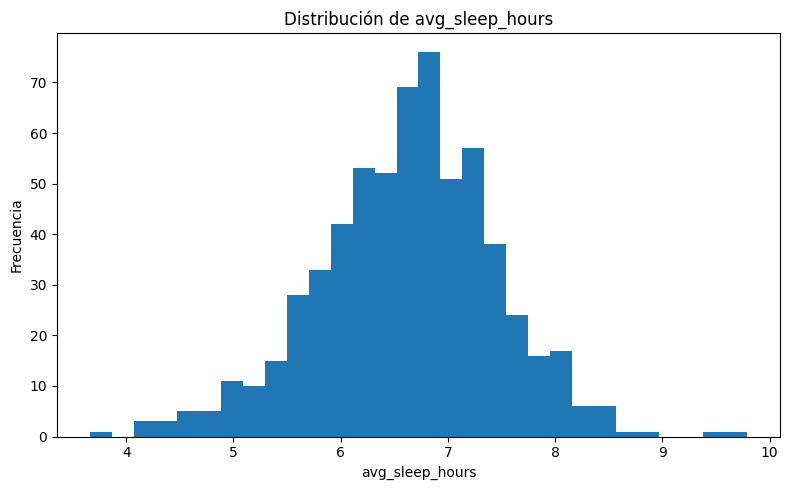

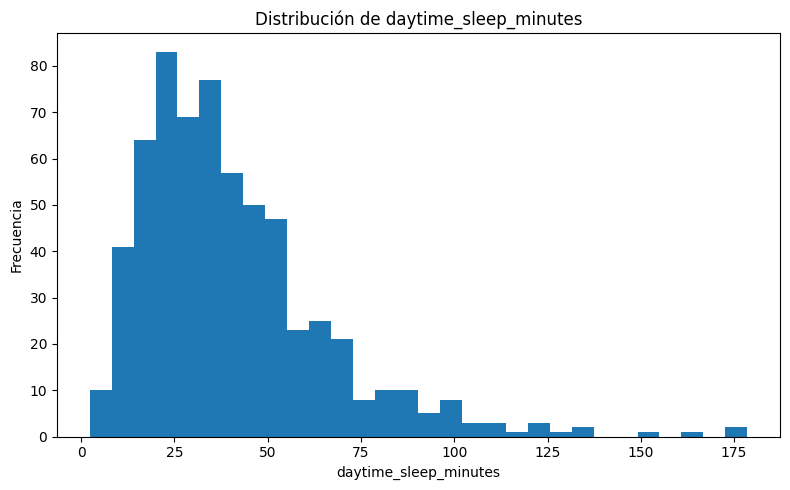

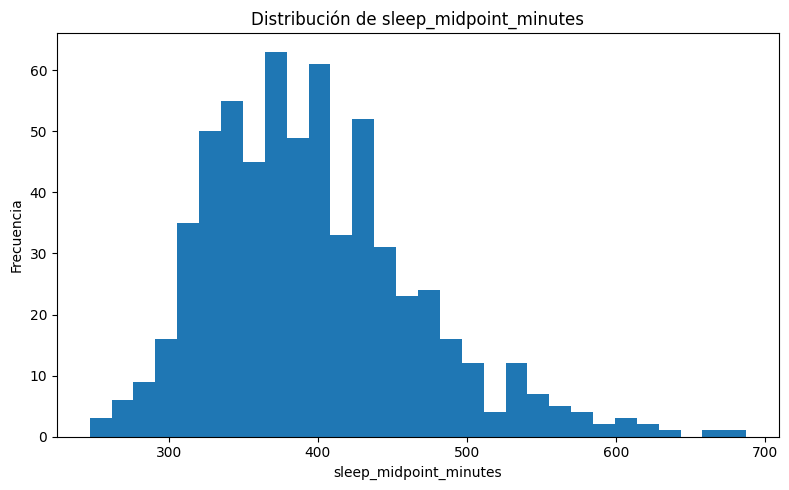

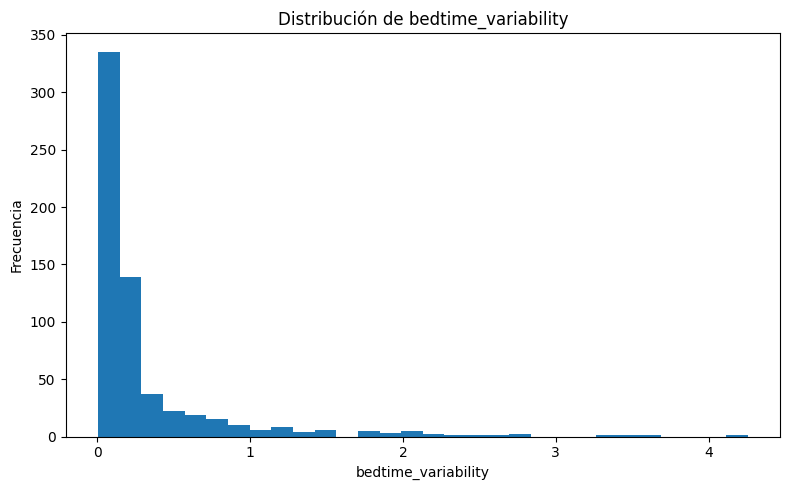

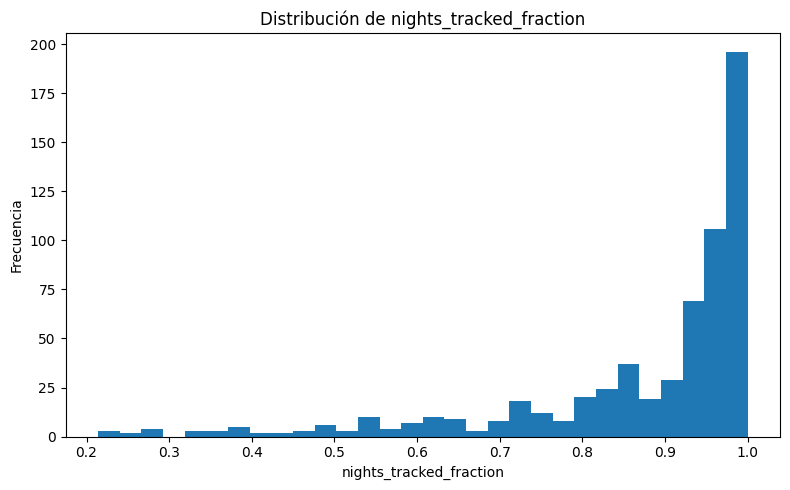

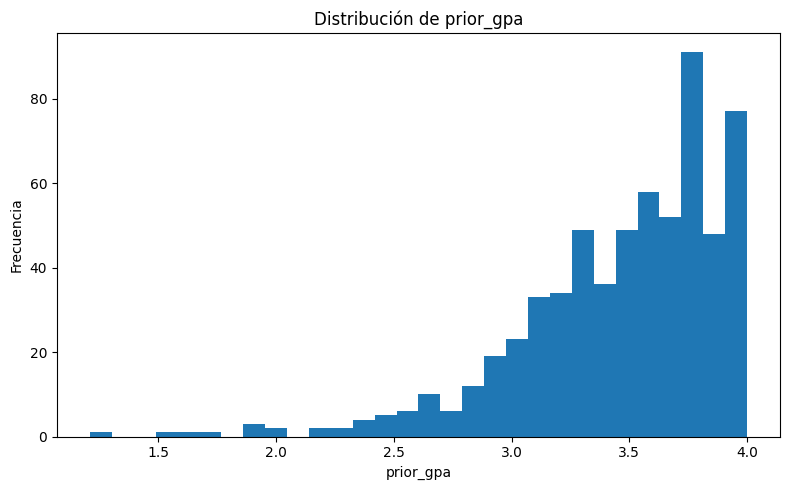

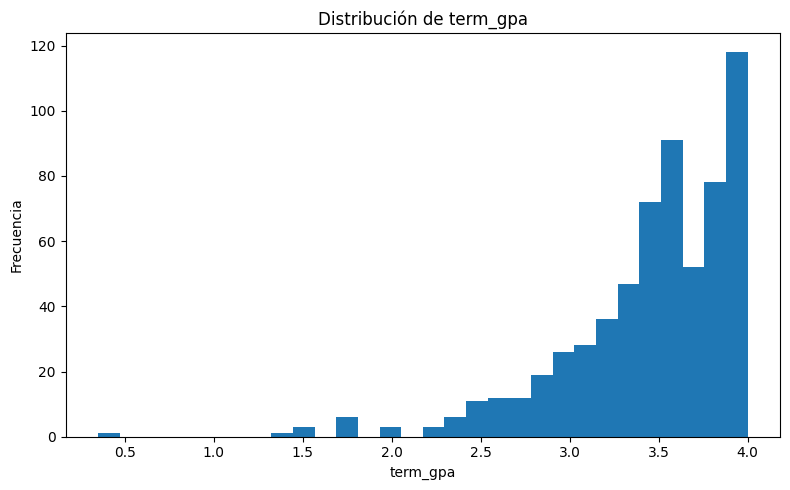

In [25]:
numeric_columns = df.select_dtypes(include=np.number).columns
for column in numeric_columns:
    plt.figure(figsize=(8, 5))
    plt.hist(df[column], bins=30)
    plt.title(f"Distribución de {column}")
    plt.xlabel(column)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

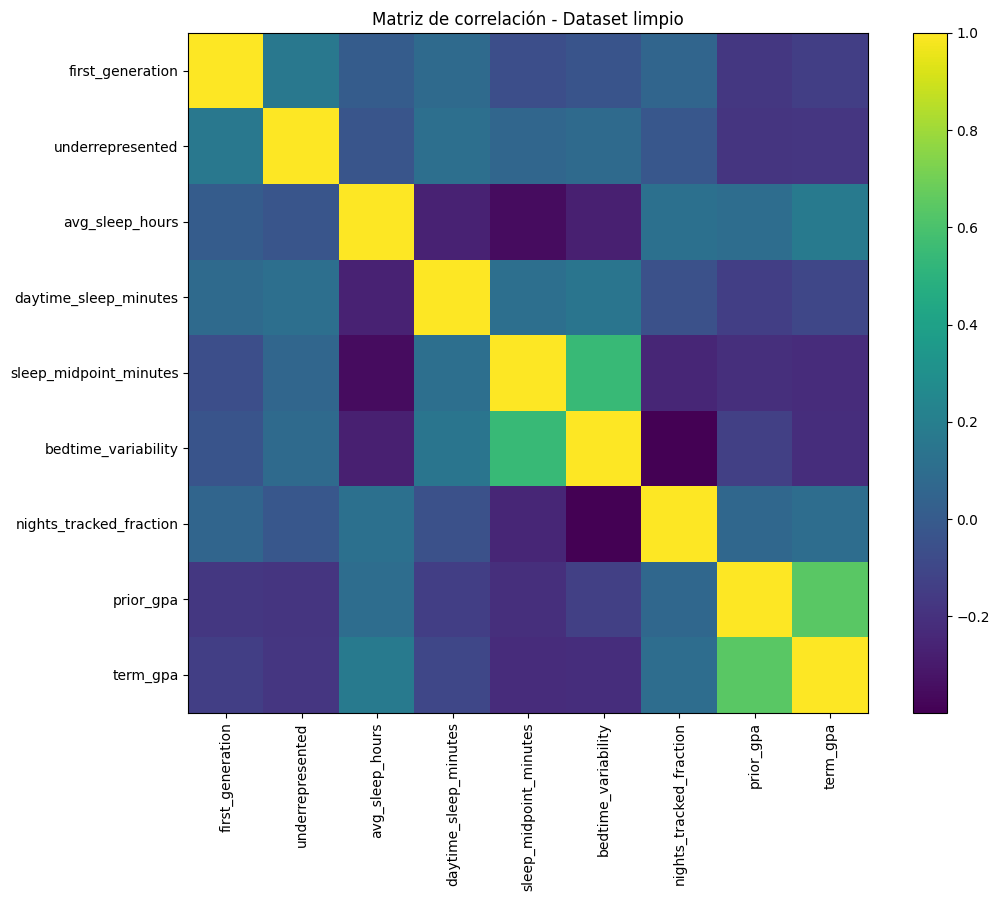

In [26]:
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(11, 9))
plt.imshow(correlation_matrix,interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)),correlation_matrix.columns,rotation=90)
plt.yticks(range(len(correlation_matrix.columns)),correlation_matrix.columns)
plt.title("Matriz de correlación - Dataset limpio")
plt.tight_layout()
plt.show()

In [27]:
target_correlation = (correlation_matrix["term_gpa"].sort_values(ascending=False))
print("Correlación con term_gpa")
print(target_correlation)

Correlación con term_gpa
term_gpa                   1.000000
prior_gpa                  0.640222
avg_sleep_hours            0.176082
nights_tracked_fraction    0.100847
daytime_sleep_minutes     -0.099399
first_generation          -0.138393
underrepresented          -0.176749
bedtime_variability       -0.214564
sleep_midpoint_minutes    -0.219471
Name: term_gpa, dtype: float64


In [28]:
corr_matrix = df.corr(numeric_only=True)
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        correlation = corr_matrix.iloc[i, j]
        if abs(correlation) >= 0.7:
            print(
                f"{corr_matrix.columns[i]} <-> "
                f"{corr_matrix.columns[j]}: "
                f"{correlation:.3f}")

In [29]:
df_x = df[["gender","first_generation","underrepresented","avg_sleep_hours","daytime_sleep_minutes","sleep_midpoint_minutes","bedtime_variability","nights_tracked_fraction","prior_gpa"]]
df_y = df[["term_gpa"]]

In [31]:
df.to_csv('df_processed.csv', index=False)
print('DataFrame exportado a df_processed.csv')

DataFrame exportado a df_processed.csv
